# Convolutional Neural Networks for Audio Detection
## Setting Up

In [1]:
# copy from drive to working directory
!cp -r /content/drive/MyDrive/COGS181_DATA /content/COGS181

In [3]:
# libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchaudio
import os
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt

In [4]:
# audio (WAV) files
## train
train_real_path = "/content/COGS181/train_real"
train_fake_path = "/content/COGS181/train_fake"

## test
test_real_path  = "/content/COGS181/test_real"
test_fake_path  = "/content/COGS181/test_fake"

In [5]:
# get the files from the folder to use
def file_to_folder(folder, label):
  files = []
  labels = []
  for filename in os.listdir(folder):
    # Exclude macOS resource fork files that start with '._'
    if filename.lower().endswith(".wav") and not filename.startswith('._'):
      files.append(os.path.join(folder, filename))
      labels.append(label)
  return files, labels

# get files and labels
## train
train_real_files, train_real_labels = file_to_folder(train_real_path, 0)
train_fake_files, train_fake_labels = file_to_folder(train_fake_path, 1)


## test
test_real_files, test_real_labels = file_to_folder(test_real_path, 0)
test_fake_files, test_fake_labels = file_to_folder(test_fake_path, 1)

## combine for train, validation, and test datasets
train_files = train_real_files + train_fake_files
train_labels = train_real_labels + train_fake_labels

test_files = test_real_files + test_fake_files
test_labels = test_real_labels + test_fake_labels

len(train_files), len(test_files)

(3750, 1250)

In [6]:
# define audiodataset
class AudioDataset(Dataset):
    def __init__(self, audio_files, labels):
        self.audio_files = audio_files
        self.labels = labels
        self.transform = torchaudio.transforms.Spectrogram()

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, idx):
        waveform, _ = torchaudio.load(self.audio_files[idx])
        spectrogram = self.transform(waveform)
        label = self.labels[idx]
        return spectrogram, label

In [7]:
# getting the train/test dataset and loader
train_dataset = AudioDataset(train_files, train_labels)
test_dataset = AudioDataset(test_files, test_labels)

train_loader = DataLoader(train_dataset, batch_size = 1, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 1)

# Neural Network VIII

Total layers: 6

Activation function: ReLU

Pooling functions: max pooling, adaptive average pool

Optimization: Adam

Regularization: Dropout

Normalization: N/A

In [ ]:
# audio CNN definition
class AudioCNN(nn.Module):
    def __init__(self):
        super(AudioCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size = 3, padding = 1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 16, kernel_size = 3, padding = 1)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(16 * 1 * 1, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.avg_pool(x)
        x = x.view(-1, 16 * 1 * 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = AudioCNN()

In [ ]:
# loss function and optimizer
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [10]:
# training the model
avg_losses = []
num_epochs = 10
print_freq = 100

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    for i, (spectrograms, labels) in enumerate(train_loader, 0):
        if spectrograms.shape[1] > 1:
            spectrograms = torch.mean(spectrograms, dim=1, keepdim=True)

        optimizer.zero_grad()
        outputs = model(spectrograms)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # not in original article but added for consistency
        if i % print_freq == print_freq - 1:
          avg_loss = running_loss / print_freq
          print("[epoch: {}, i: {:5d}] avg mini-batch loss: {: .3f}".format(epoch, i, avg_loss))
          avg_losses.append(avg_loss)
          running_loss = 0.0

print("Finished Training.")

[epoch: 0, i:    99] avg mini-batch loss:  0.719
[epoch: 0, i:   199] avg mini-batch loss:  0.686
[epoch: 0, i:   299] avg mini-batch loss:  0.616
[epoch: 0, i:   399] avg mini-batch loss:  0.605
[epoch: 0, i:   499] avg mini-batch loss:  0.632
[epoch: 0, i:   599] avg mini-batch loss:  0.644
[epoch: 0, i:   699] avg mini-batch loss:  0.603
[epoch: 0, i:   799] avg mini-batch loss:  0.588
[epoch: 0, i:   899] avg mini-batch loss:  0.636
[epoch: 0, i:   999] avg mini-batch loss:  0.623
[epoch: 0, i:  1099] avg mini-batch loss:  0.606
[epoch: 0, i:  1199] avg mini-batch loss:  0.558
[epoch: 0, i:  1299] avg mini-batch loss:  0.537
[epoch: 0, i:  1399] avg mini-batch loss:  0.664
[epoch: 0, i:  1499] avg mini-batch loss:  0.598
[epoch: 0, i:  1599] avg mini-batch loss:  0.610
[epoch: 0, i:  1699] avg mini-batch loss:  0.549
[epoch: 0, i:  1799] avg mini-batch loss:  0.680
[epoch: 0, i:  1899] avg mini-batch loss:  0.547
[epoch: 0, i:  1999] avg mini-batch loss:  0.575
[epoch: 0, i:  2099]

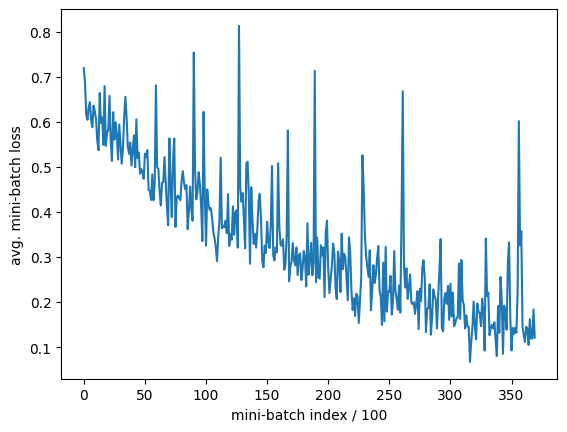

In [11]:
# training loss curve
plt.plot(avg_losses)
plt.xlabel('mini-batch index / {}'.format(print_freq))
plt.ylabel('avg. mini-batch loss')
plt.show()

In [12]:
# test the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for spectrograms, labels in test_loader:
        if spectrograms.shape[1] > 1:
            spectrograms = torch.mean(spectrograms, dim=1, keepdim=True)

        outputs = model(spectrograms)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total}%')

Accuracy: 68.88%
